# Module 2 – Stochastic Hydrology Analysis
## Main Notebook

All analysis functions live in **`hydro_functions.py`** (same folder).


In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import hydro_functions
import hydro_functions_v2
importlib.reload(hydro_functions)
importlib.reload(hydro_functions_v2)
from scipy import stats

from hydro_functions_v2 import (
    log_transform, test_and_detrend, seasonal_standardise,
    gap_aware_acf_pacf, plot_acf_pacf,
    select_order_from_acf_pacf, candidate_models, fit_best_models,
    theoretical_acf, evaluate_all_models,
    ppcc_test, ppcc_critical_test, ljungbox_test, detect_gaps,
)


## 1. Data loading and preparation

In [207]:
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
#root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'

qD   = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'),       parse_dates=['timestamp']).set_index('timestamp')
qG   = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'),   parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'),      parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')


In [208]:
# Resample to monthly means
qD   = qD.resample('ME').mean()
qG   = qG.resample('ME').mean()
sscD = sscD.resample('ME').mean()
sscG = sscG.resample('ME').mean()

"""
# Ensure a monthly-frequency index
qD   = ensure_monthly_freq(qD)
qG   = ensure_monthly_freq(qG)
sscD = ensure_monthly_freq(sscD)
sscG = ensure_monthly_freq(sscG)
"""

# Detect gaps on raw monthly data
print('\n=== Gap detection ===')
gap_dates = {}
for key, df in [('Q_Diepoldsau', qD),   ('Q_Gisingen', qG),
                ('C_Diepoldsau', sscD),  ('C_Gisingen', sscG)]:
    col = df.columns[0]
    gap_dates[key] = detect_gaps(df[col], min_gap_months=2)
    if gap_dates[key] is None:
        print(f'  {key}: no significant gap')
    else:
        print(f'  {key}: first significant gap starts {gap_dates[key].date()}')

print()
print('Monthly sample sizes:')
print(f'  Q   Diepoldsau : {len(qD.dropna())} months')
print(f'  Q   Gisingen   : {len(qG.dropna())} months')
print(f'  SSC Diepoldsau : {len(sscD.dropna())} months')
print(f'  SSC Gisingen   : {len(sscG.dropna())} months')


=== Gap detection ===
  Q_Diepoldsau: no significant gap
  Q_Gisingen: no significant gap
    Gap detected: starts 2019-01-31, length=2 months
  C_Diepoldsau: first significant gap starts 2019-01-31
    Gap detected: starts 2009-01-31, length=12 months
  C_Gisingen: first significant gap starts 2009-01-31

Monthly sample sizes:
  Q   Diepoldsau : 507 months
  Q   Gisingen   : 564 months
  SSC Diepoldsau : 169 months
  SSC Gisingen   : 192 months


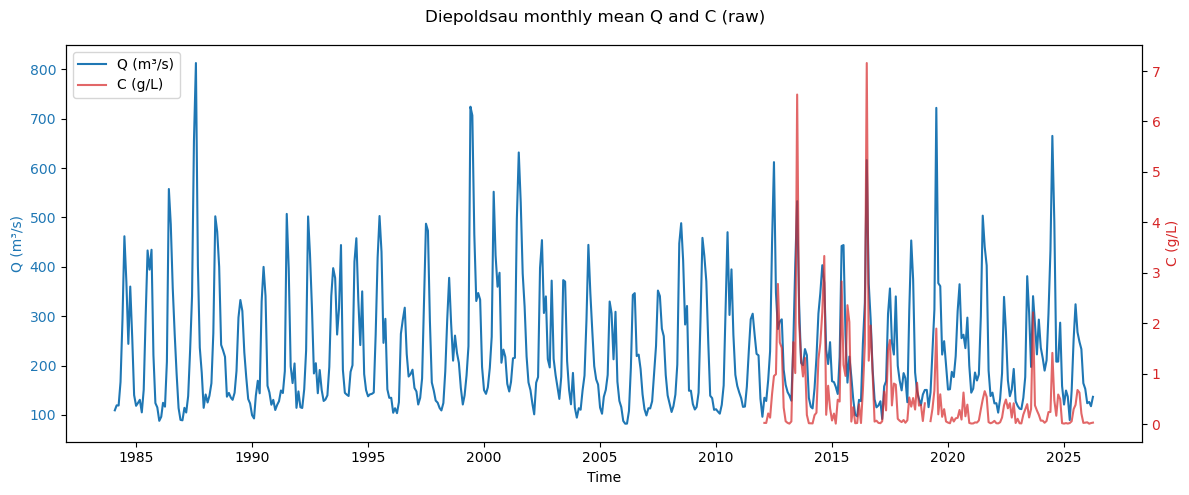

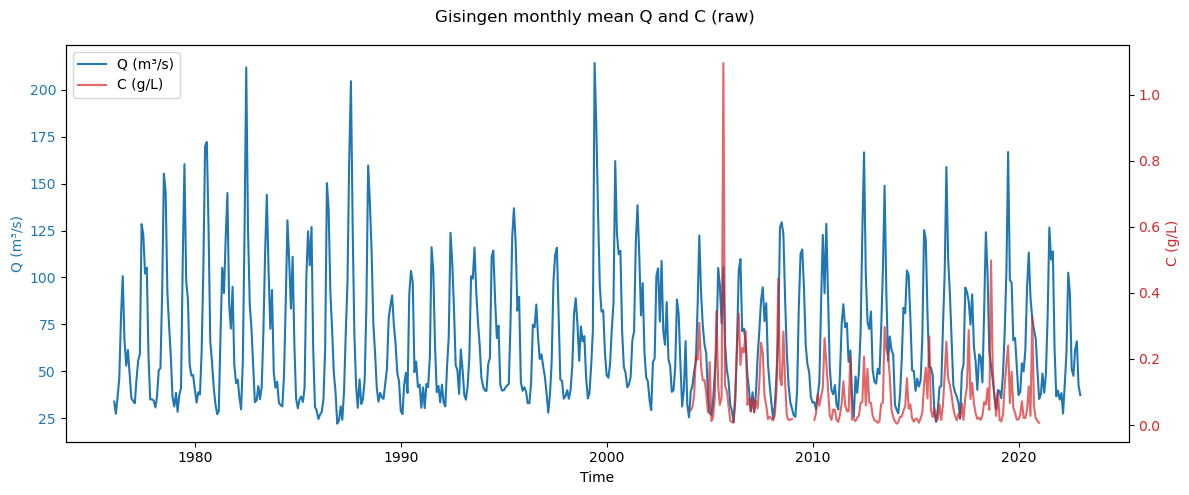

In [209]:
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='Q (m³/s)', color='tab:blue')
    ax.set_xlabel('Time'); ax.set_ylabel('Q (m³/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:, 0], label='C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines  = ax.get_legend_handles_labels()
    lines2 = ax2.get_legend_handles_labels()
    ax.legend(lines[0]+lines2[0], lines[1]+lines2[1], loc='upper left')
    fig.suptitle(f'{station} monthly mean Q and C (raw)')
    fig.tight_layout(); plt.show()


Do they look stationary? Do you notice trends?
No trend visible, but we can see clearly that the Suspended Sediment concentration decreases drastically after the year 2005 in Gisingen and after year 2017 in Diepoldsau.

## 1.1 Log transformation
Q and SSC are strictly positive and span several orders of magnitude.
Applying ln(x) before detrending and deseasonalising:
- removes positive skewness (log-normal assumption, standard in hydrology)
- stabilises variance across months
- ensures detrending and seasonal means are estimated on a symmetric series

Box-Cox λ ≈ 0 confirms the log is the appropriate transformation.


In [210]:
qD_log   = log_transform(qD,   'q_m3s')
qG_log   = log_transform(qG,   'q_m3s')
sscD_log = log_transform(sscD, sscD.columns[0])
sscG_log = log_transform(sscG, sscG.columns[0])

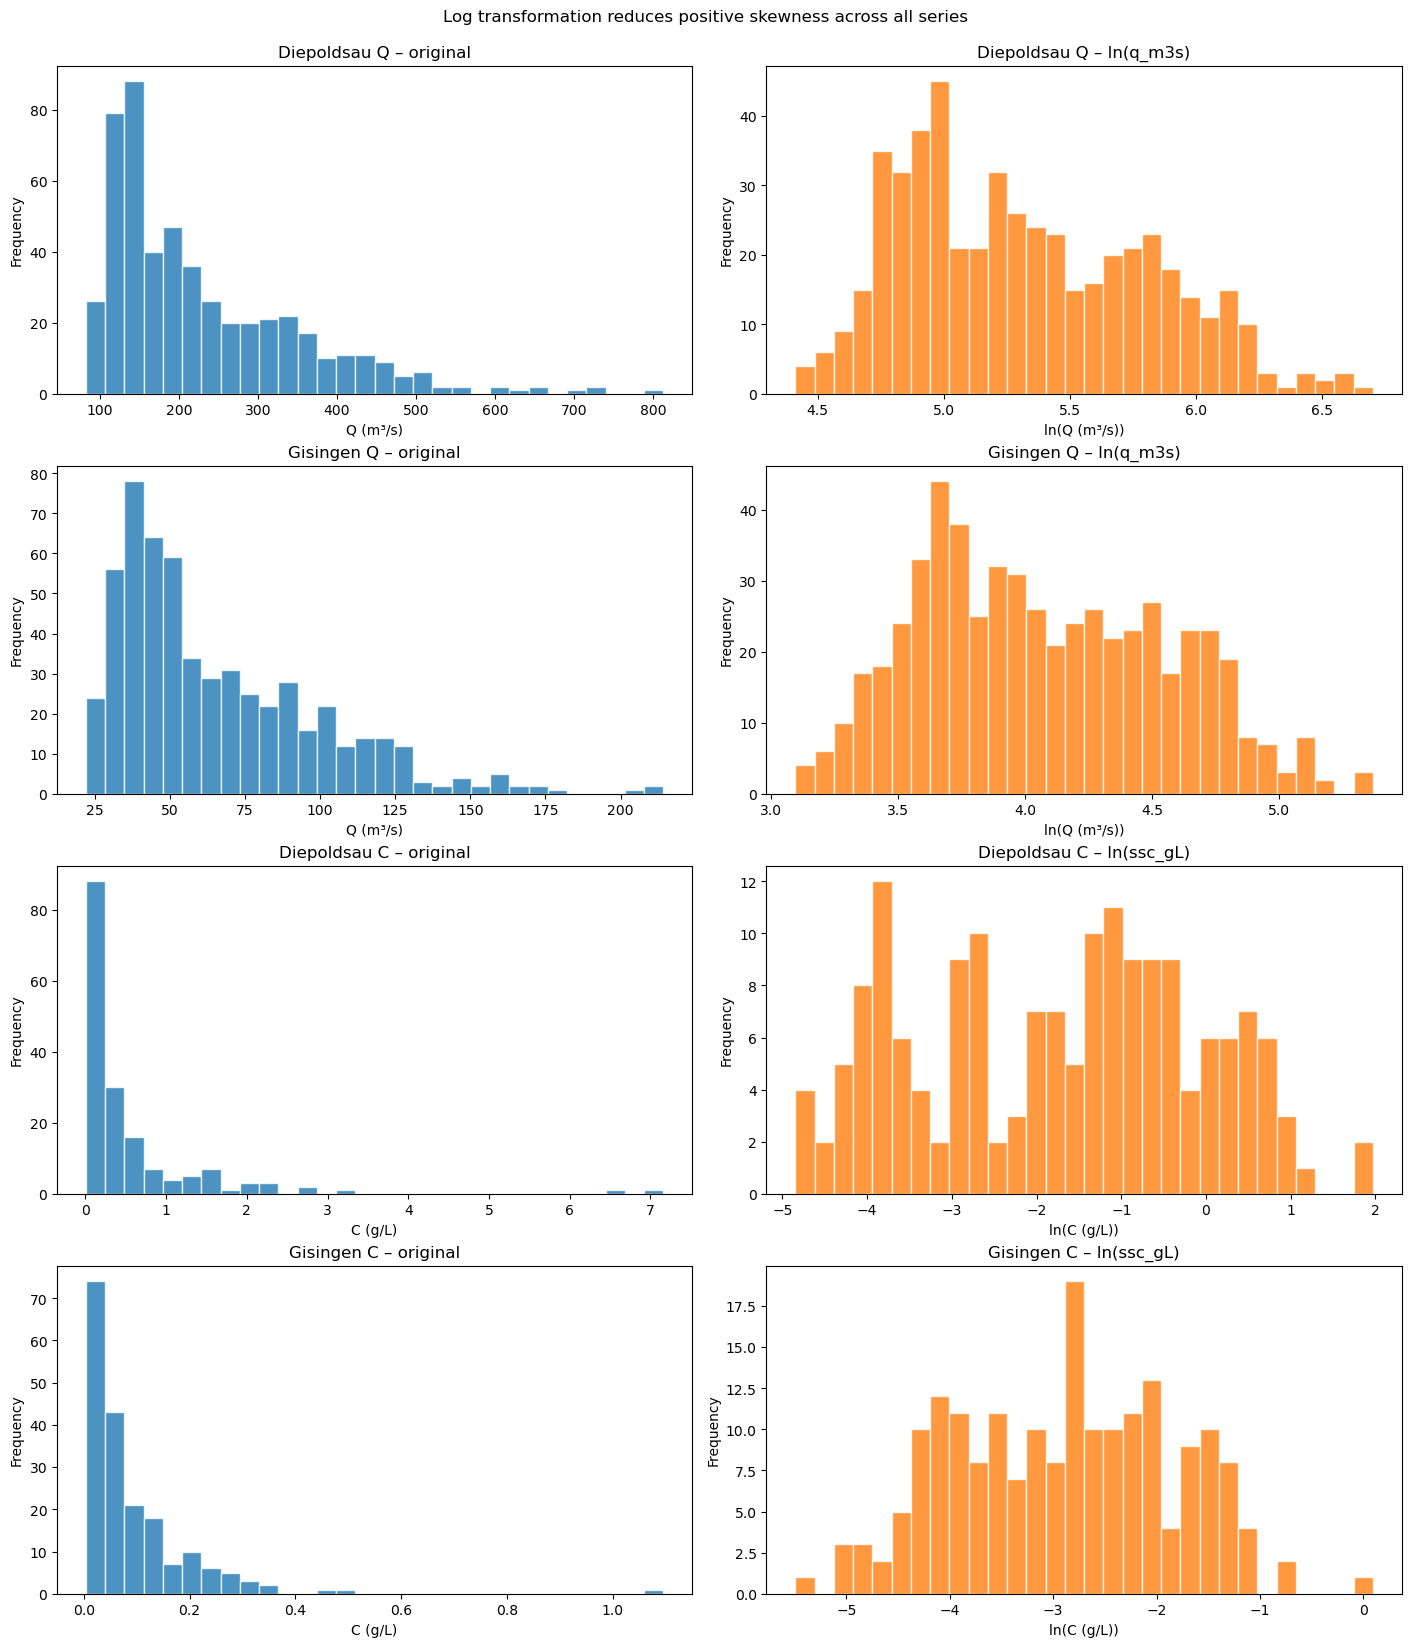

In [211]:
series_info = [
    ('Diepoldsau Q', qD_log, 'q_m3s', 'Q (m³/s)'),
    ('Gisingen Q', qG_log, 'q_m3s', 'Q (m³/s)'),
    ('Diepoldsau C', sscD_log, sscD_log.columns[0], 'C (g/L)'),
    ('Gisingen C', sscG_log, sscG_log.columns[0], 'C (g/L)'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)
for i, (title, df, col, orig_label) in enumerate(series_info):
    raw = np.exp(df[col].dropna())
    axes[i, 0].hist(raw, bins=30, color='tab:blue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{title} – original')
    axes[i, 0].set_xlabel(orig_label)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(df[col].dropna(), bins=30, color='tab:orange', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{title} – ln({col})')
    axes[i, 1].set_xlabel(f'ln({orig_label})')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Log transformation reduces positive skewness across all series', y=1.02)
plt.show()


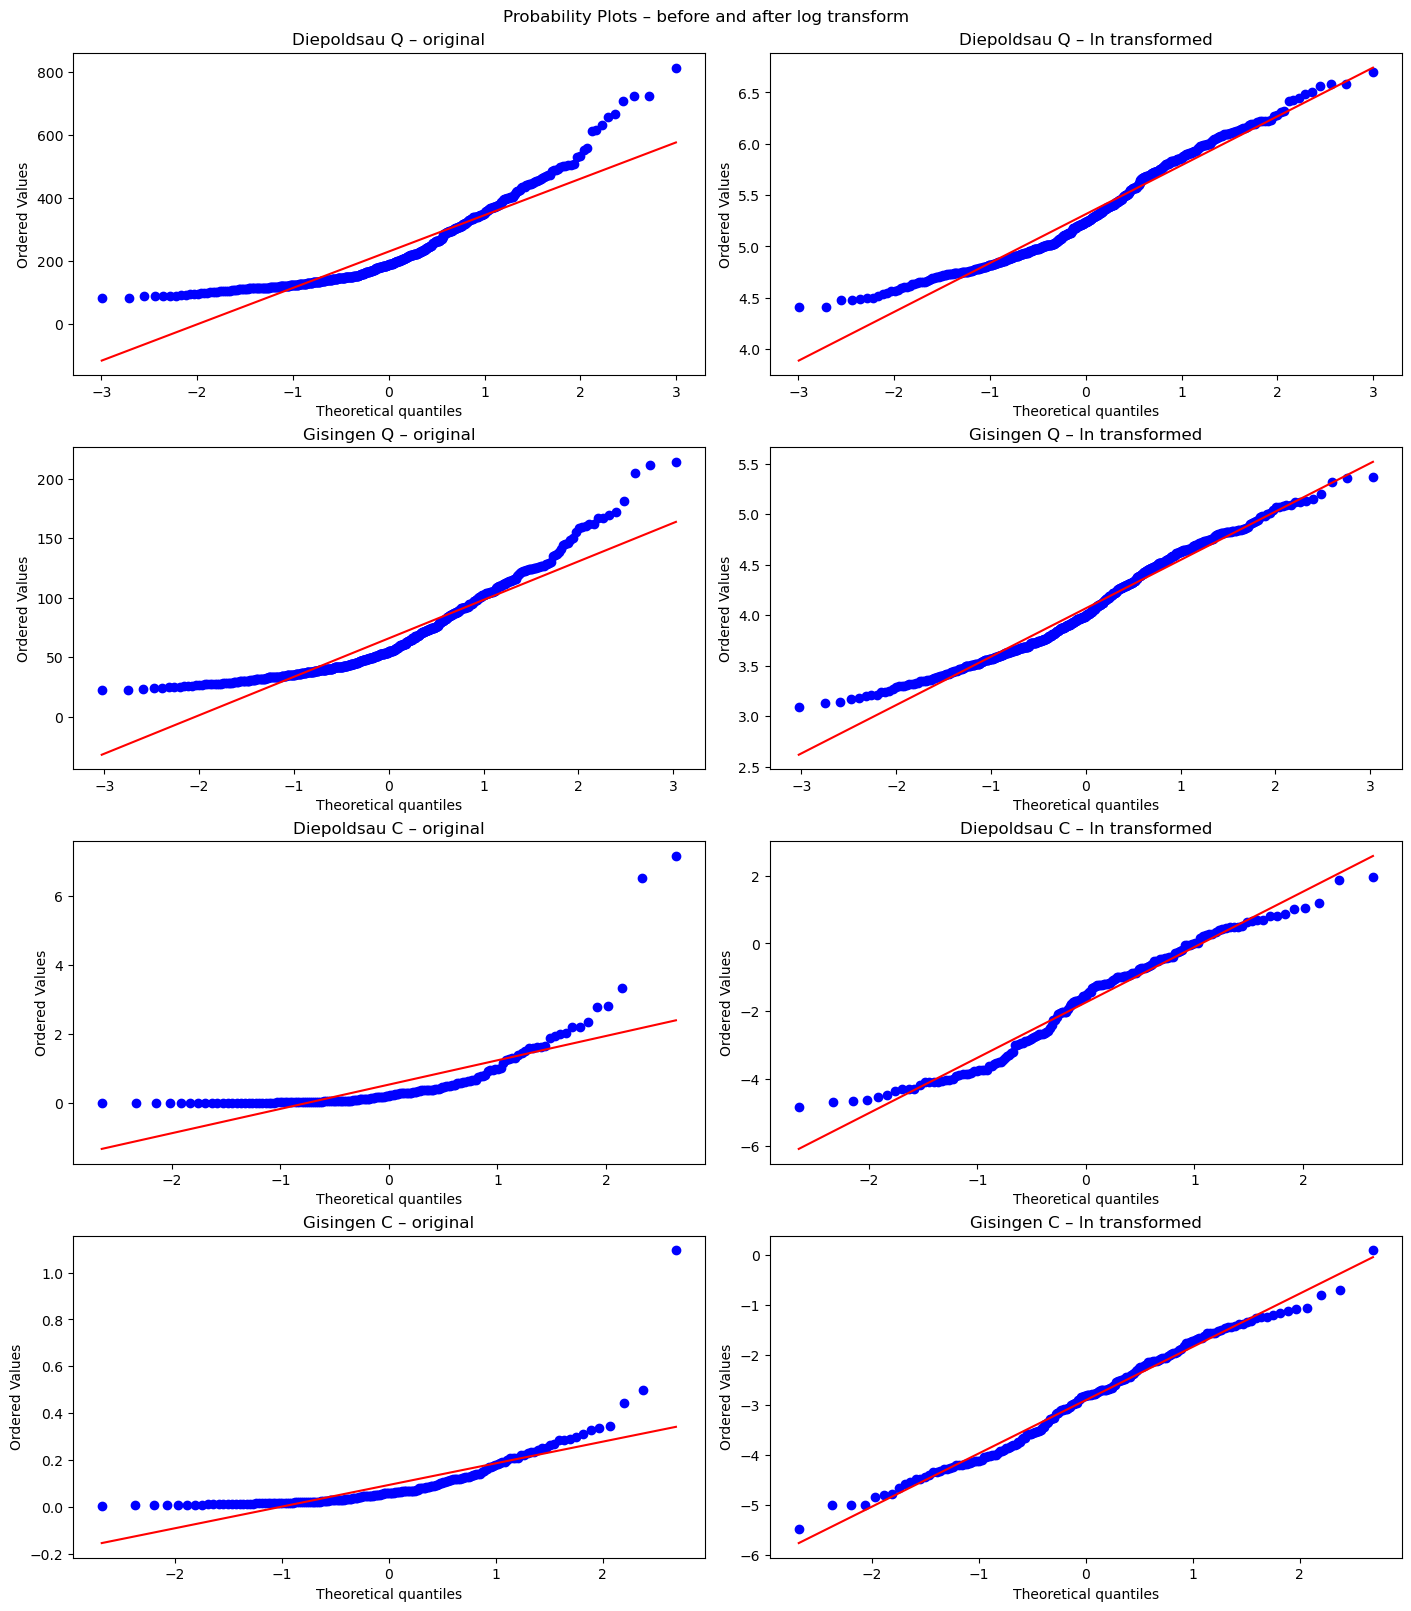

In [212]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)

for i, (title, df, col, orig_label) in enumerate(series_info):
    raw = np.exp(df[col].dropna())

    # Original
    stats.probplot(raw, dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f'{title} – original')

    # Log-transformed
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{title} – ln transformed')

plt.suptitle('Probability Plots – before and after log transform')
plt.show()

In [213]:
for title, df, col, _ in series_info:
    raw     = np.exp(df[col].dropna())
    skew_raw = stats.skew(raw)
    skew_log = stats.skew(df[col].dropna())
    print(f"{title:20s} | Skew original: {skew_raw:6.3f} | Skew log: {skew_log:6.3f}")

Diepoldsau Q         | Skew original:  1.430 | Skew log:  0.453
Gisingen Q           | Skew original:  1.240 | Skew log:  0.298
Diepoldsau C         | Skew original:  4.163 | Skew log: -0.050
Gisingen C           | Skew original:  4.231 | Skew log:  0.013


## Log Transformation

All four series (Q and C at both stations) show strong positive skewness in their original values.
A natural log transformation (`ln`) is applied to all series to reduce skewness and approximate normality.
This is standard practice in hydrology, as streamflow and sediment concentration data typically follow a log-normal distribution.

## 1.2 Stationarity test and trend removal
Linear trend test at 5 % significance on ln(Q) and ln(C).
A significant slope in log-space = exponential trend in original units.
If significant: subtract fitted linear trend.
If not: subtract global mean.


In [214]:
station_results  = []
transform_info = {}
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD_log, sscD_log), ('Gisingen', qG_log, sscG_log)]:
    for var, df, col in [('Q', dfQ, 'q_m3s'), ('C', dfC, dfC.columns[0])]:
        key = f'{var}_{station}'
        # 1) Seasonal standardisation on ln(x)
        z, m_mean, m_std = seasonal_standardise(df[col].dropna())
        # 2) Test for trend and detrend the seasonally-standardised series
        det, res = test_and_detrend(z.to_frame(name=col), col)
        # store the detrended (seasonal-standardised then detrended) series
        detrended_series[key] = det.squeeze()
        transform_info[key] = {
            'month_mean': m_mean,
            'month_std': m_std,
            'detrend': res,
        }
        station_results.append({'station': station, 'variable': var, **res})

,0,1,2,3
station,Diepoldsau,Diepoldsau,Gisingen,Gisingen
variable,Q,C,Q,C
n_points,507,169,564,192
intercept,-0.079758,0.766175,-0.017708,0.487706
slope,0.000315,-0.009121,0.000063,-0.005107
pvalue,0.293997,0.0,0.806211,0.000039
significant,False,True,False,True
detrend_method,mean,linear trend,mean,linear trend
mean_after_detrend,0.0,0.0,0.0,0.0
variance_after_detrend,0.978261,0.735341,0.980462,0.861873


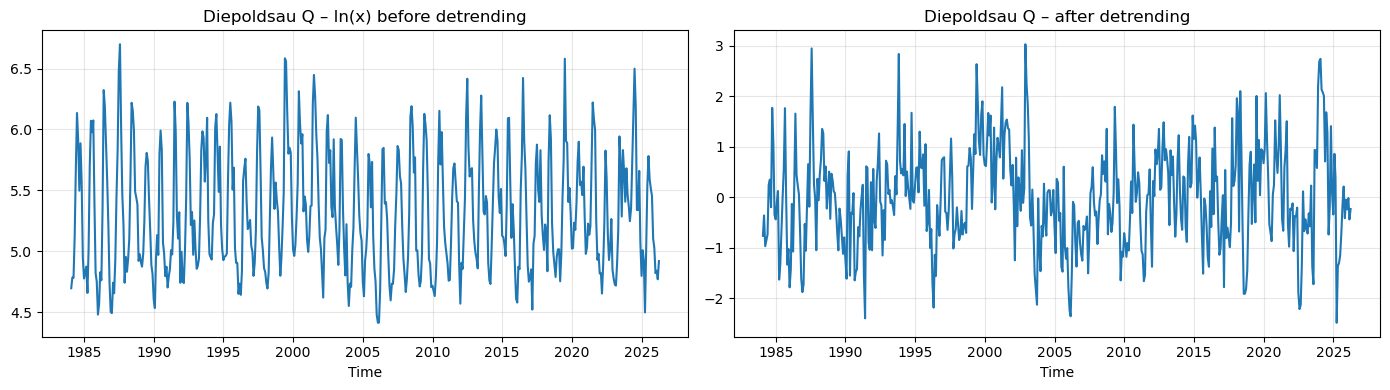

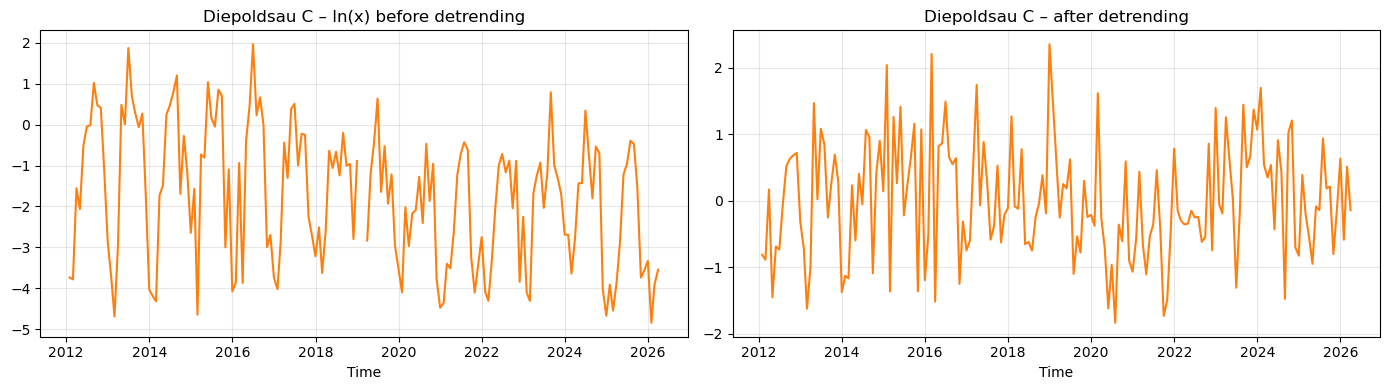

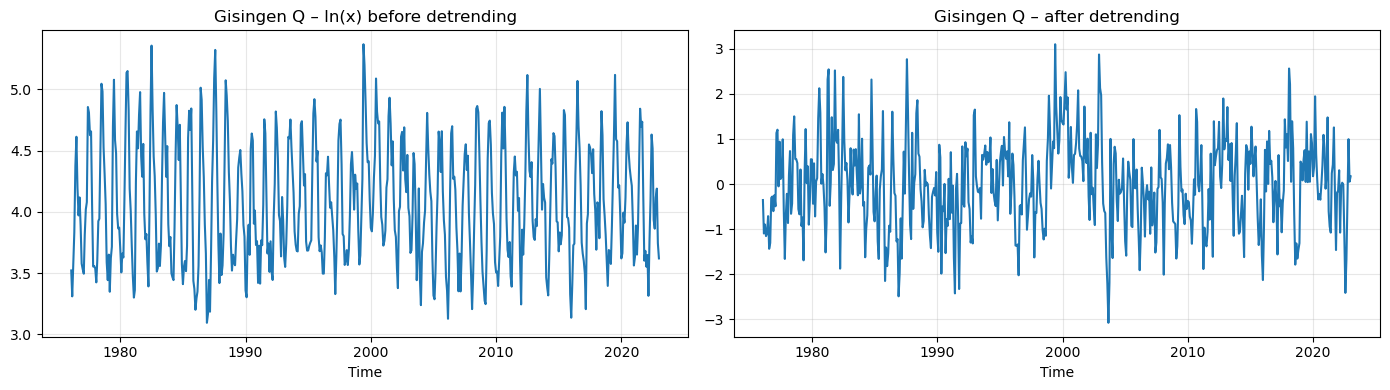

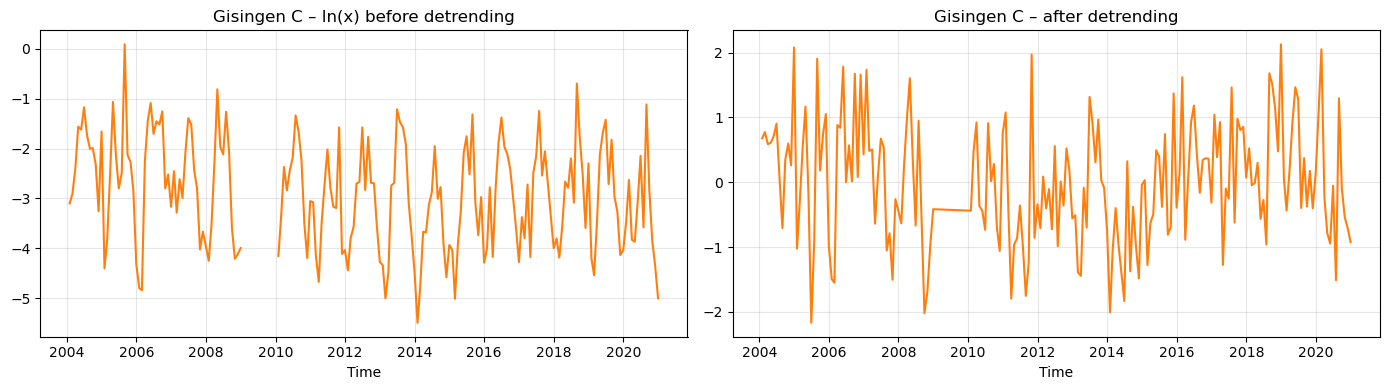

In [215]:
display(pd.DataFrame(station_results).T)

# Plot original vs detrended for each series
for station in ['Diepoldsau', 'Gisingen']:
    for var in ['Q', 'C']:
        key = f'{var}_{station}'
        det = detrended_series[key]
        orig_map = {
            ('Diepoldsau', 'Q'): qD_log,
            ('Gisingen', 'Q'): qG_log,
            ('Diepoldsau', 'C'): sscD_log,
            ('Gisingen', 'C'): sscG_log,
        }
        original = orig_map[(station, var)]
        col = 'q_m3s' if var == 'Q' else original.columns[0]
        color = 'tab:blue' if var == 'Q' else 'tab:orange'
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
        a1.plot(original.index, original[col], color=color)
        a1.set_title(f'{station} {var} – ln(x) before detrending')
        a2.plot(det.index, det, color=color)
        a2.set_title(f'{station} {var} – after detrending')
        for a in [a1, a2]:
            a.set_xlabel('Time'); a.grid(alpha=0.3)
        plt.tight_layout(); plt.show()



In [216]:
import numpy as np
from scipy.stats import linregress

series_map = {
    'Diepoldsau Q': qD_log['q_m3s'],
    'Gisingen Q': qG_log['q_m3s'],
    'Diepoldsau C': sscD_log[sscD_log.columns[0]],
    'Gisingen C': sscG_log[sscG_log.columns[0]],
}

for name, series in series_map.items():
    y = series.dropna().values
    x = np.arange(len(y))
    res = linregress(x, y)

    print(f"=== {name} ===")
    print(f"slope   = {res.slope:.6f}")
    print(f"p-value = {res.pvalue:.6f}")
    if res.pvalue < 0.05:
        print("Trend ist bei 5 % Signifikanz signifikant.")
    else:
        print("Trend ist bei 5 % Signifikanz nicht signifikant.")
    print()

=== Diepoldsau Q ===
slope   = 0.000025
p-value = 0.866022
Trend ist bei 5 % Signifikanz nicht signifikant.

=== Gisingen Q ===
slope   = 0.000000
p-value = 0.997213
Trend ist bei 5 % Signifikanz nicht signifikant.

=== Diepoldsau C ===
slope   = -0.009834
p-value = 0.000115
Trend ist bei 5 % Signifikanz signifikant.

=== Gisingen C ===
slope   = -0.003792
p-value = 0.005743
Trend ist bei 5 % Signifikanz signifikant.



The data are first transformed using logarithms to stabilize variance and linearize multiplicative relationships.
Next, seasonal effects are removed by subtracting the monthly climatological mean and scaling by the corresponding monthly standard deviation.
Finally, the linear trend component is removed from the processed time series to obtain a more stationary series suitable for statistical analysis.

## 2. Seasonal standardisation and ACF / PACF

After log-transform and detrending the series still has a 12-month seasonal
cycle. We remove it via seasonal standardisation (Method 1, §6.5.3):

    z_t = (ln(x_t) − mean_month) / std_month

For SSC series (C) the professor flagged data gaps:
- Diepoldsau 2019 → split series, compute ACF/PACF on each segment, average
- Gisingen   2009 → same

We report the Pearson r between the two segment ACFs to check whether
the autocorrelation structure changed across the gap.



=== Diepoldsau Q ===
  Checking for data gaps...
  No significant gap found, using full series.


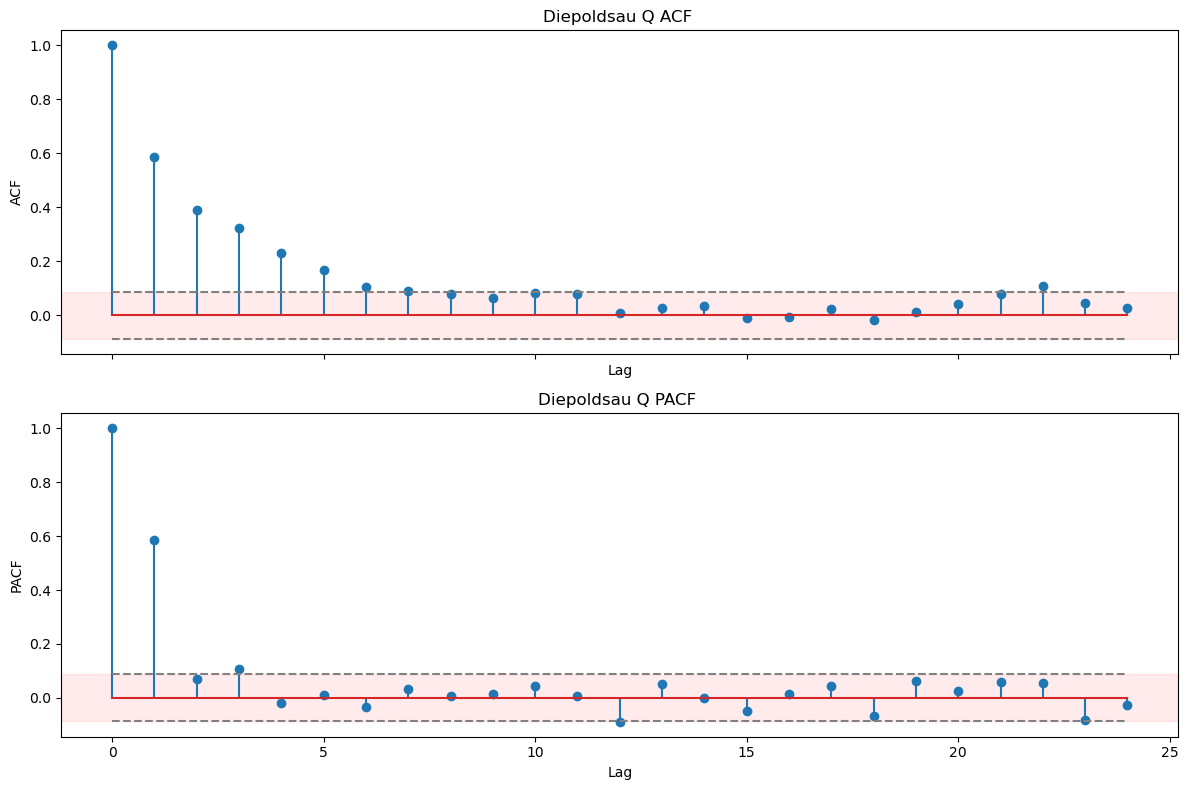


=== Diepoldsau C ===
  Checking for data gaps...
  Using gap at 2019-01-31 for ACF/PACF splitting.


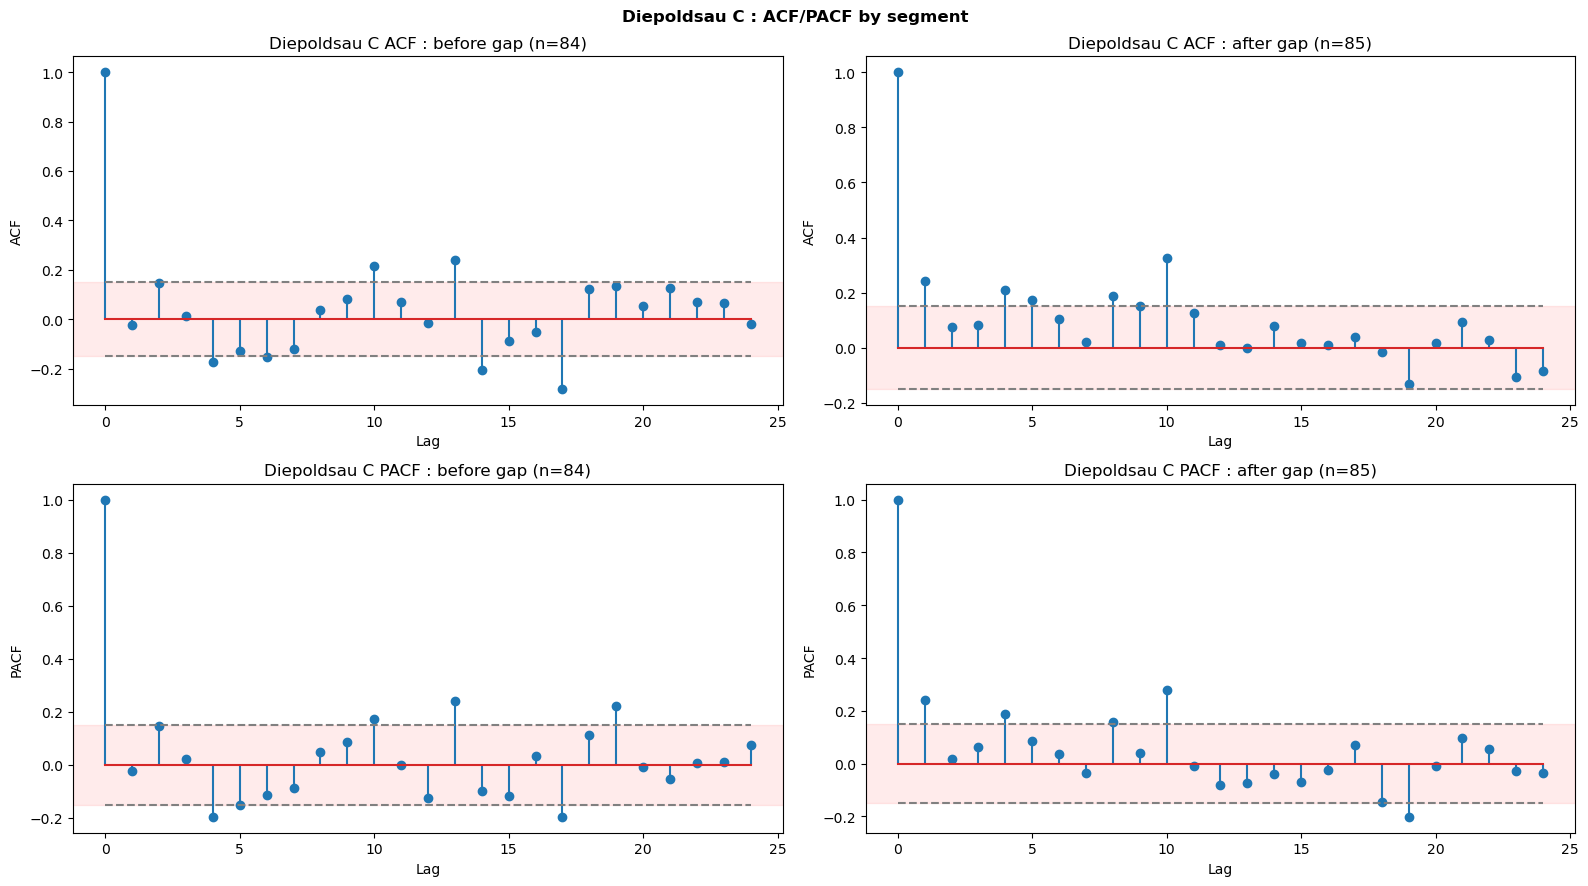

    Pearson r between segment ACFs: -0.059 (different : worth discussing in report)


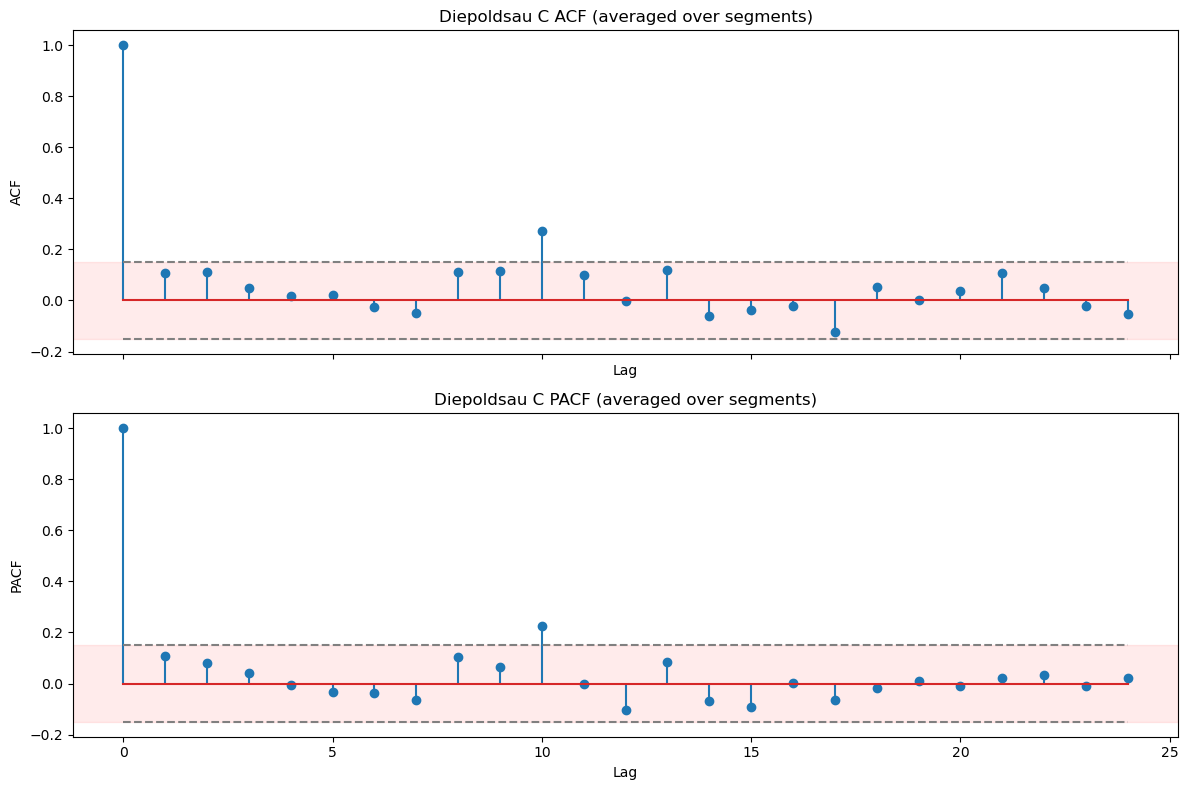


=== Gisingen Q ===
  Checking for data gaps...
  No significant gap found, using full series.


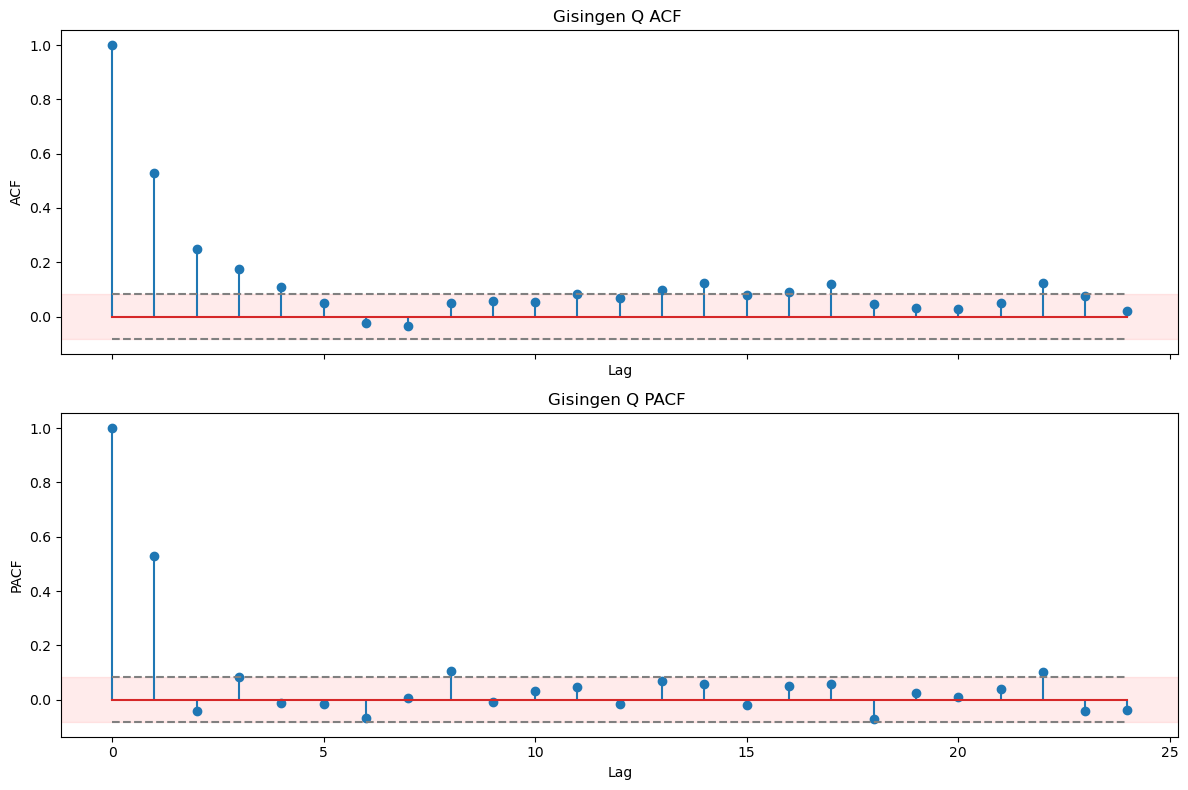


=== Gisingen C ===
  Checking for data gaps...
  Using gap at 2009-01-31 for ACF/PACF splitting.


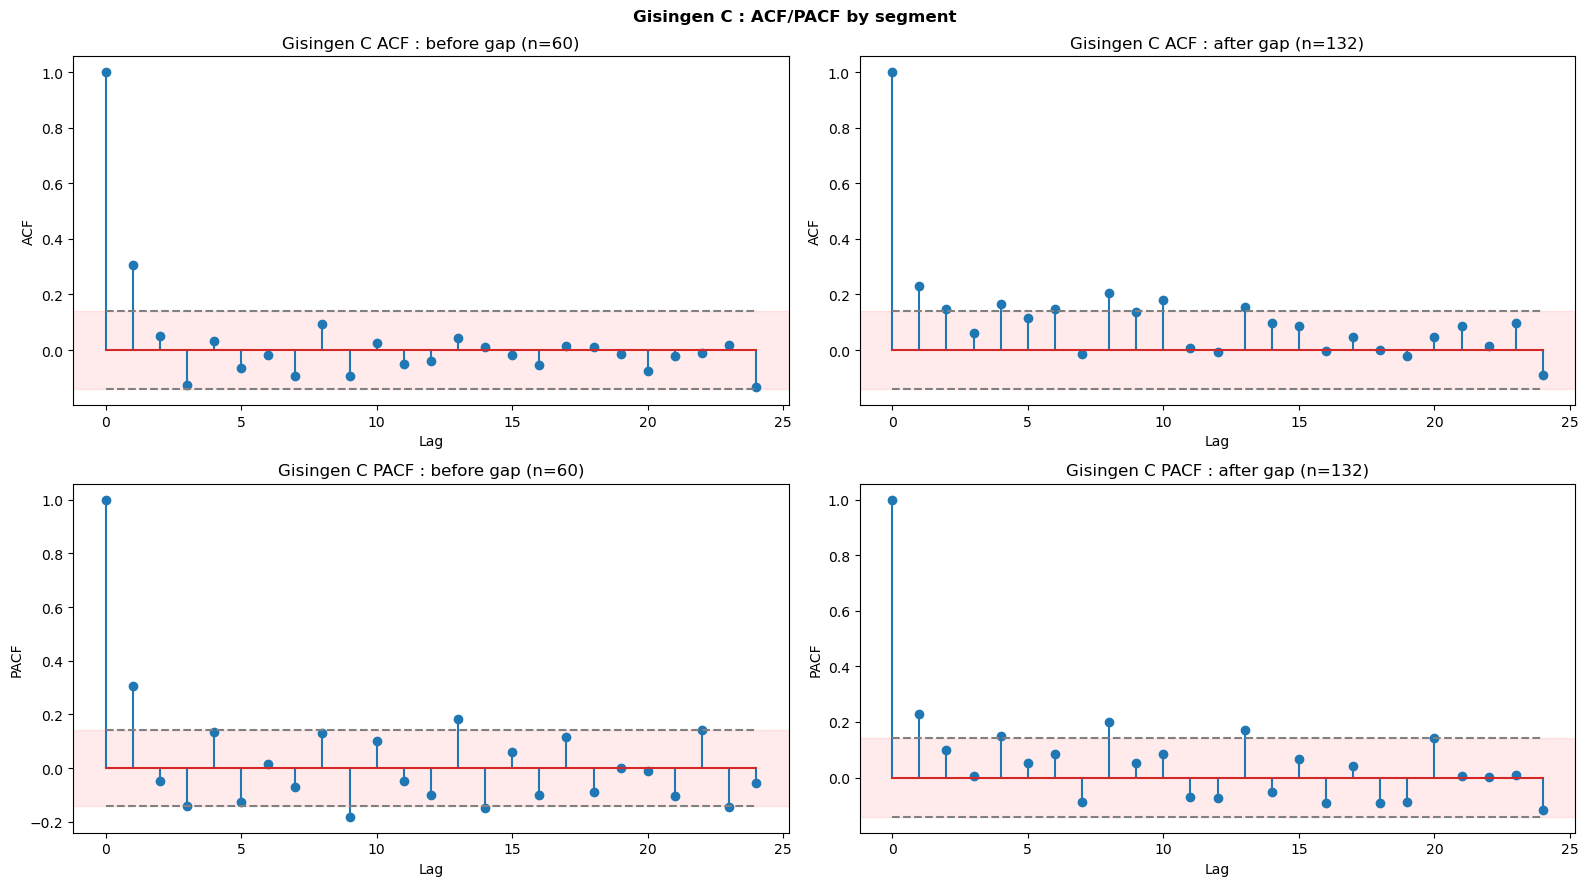

    Pearson r between segment ACFs: 0.657 (different : worth discussing in report)


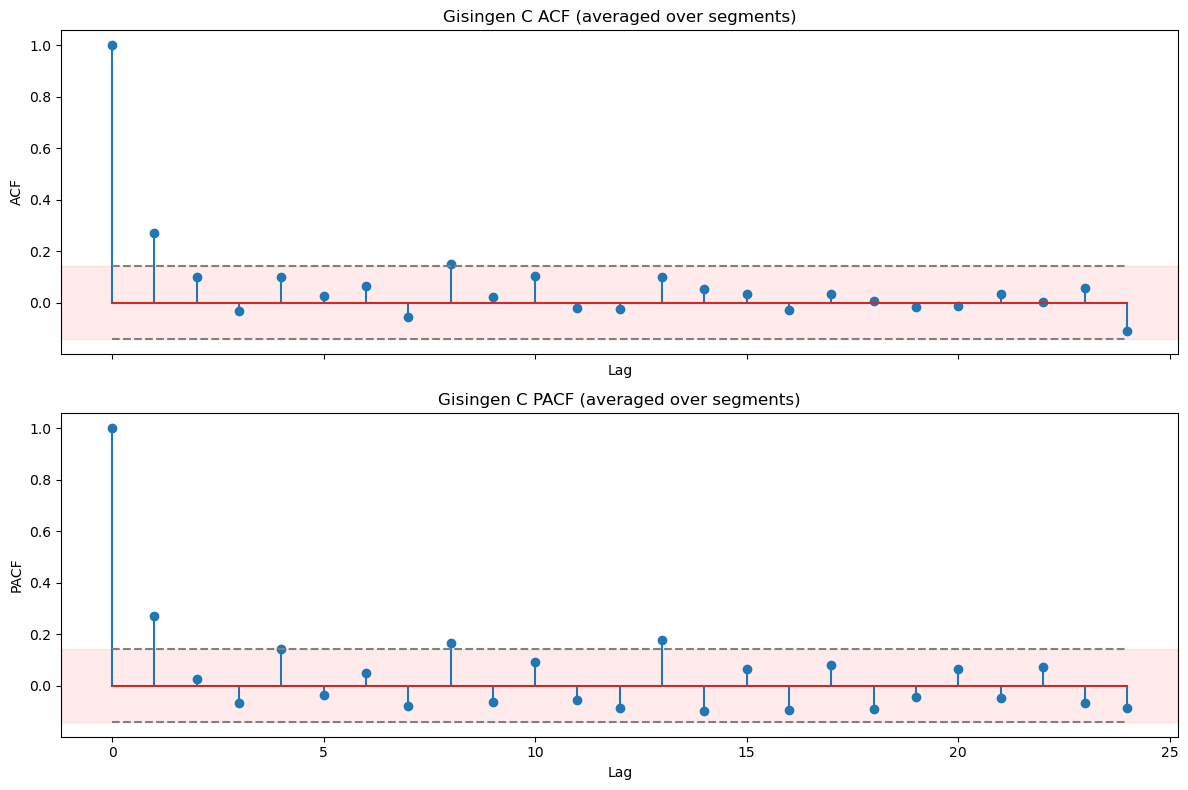

In [217]:
max_lag  = 24
z_series = {}

for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)
    print(f'\n=== {station} {variable} ===')

    # The series in `detrended_series` is already seasonally-standardised then detrended.
    z = raw_series.dropna()
    z_series[key] = z

    # Auto-detect gaps from the raw series
    print(f'  Checking for data gaps...')
    gap_date = gap_dates.get(key)
    if gap_date is None:
        print(f'  No significant gap found, using full series.')
    else:
        print(f'  Using gap at {gap_date.date()} for ACF/PACF splitting.')

    acf_avg, pacf_avg, conf, segments = gap_aware_acf_pacf(
        z, max_lag, gap_date)
    plot_acf_pacf(station, variable, acf_avg, pacf_avg, conf, segments, max_lag)

## 2.2 AR and ARMA model fitting

Fit on the fully pre-processed z_series (log + detrended + deseasonalised).

Model selection:
- Scan AR(1..max_ar) and ARMA(1..max_ar, 1..3), ranked by BIC.
- Default max_ar = 4. Q Gisingen uses max_ar = 6 because its residuals
  showed long-lag autocorrelation at lag 24 with a lower-order model.
- All orders well within the professor's cap of 12.


In [218]:
z_series = {}
for key, raw_series in detrended_series.items():
    z_series[key] = raw_series.dropna()

In [219]:
fitted_models = fit_best_models(z_series)


## 3. Model evaluation

For each fitted model:
- (a) Empirical vs theoretical ACF (using ArmaProcess with fitted params)
- (b) Residual ACF — all lags should be within the 95% CI
- (c) Probability plot (visual normality check)



===== Diepoldsau Q Evaluation =====


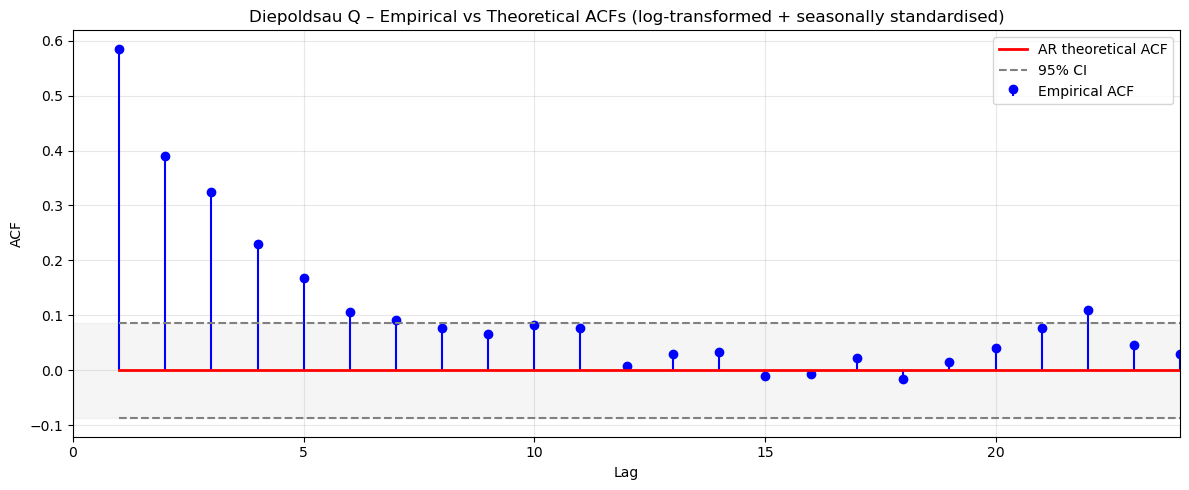

  AR: too few residuals (n=0), skipping.

===== Diepoldsau C Evaluation =====


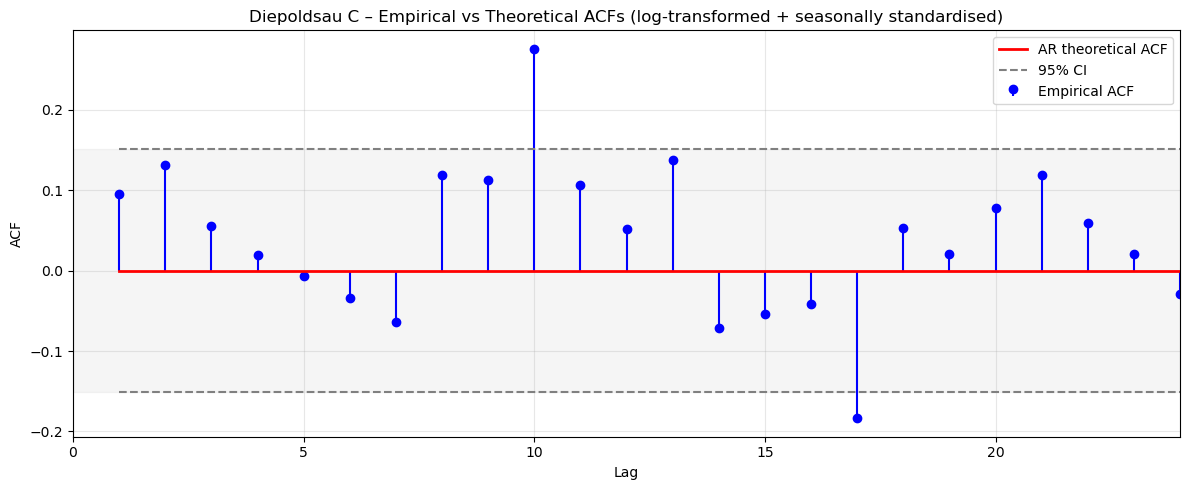

  AR: too few residuals (n=0), skipping.

===== Gisingen Q Evaluation =====


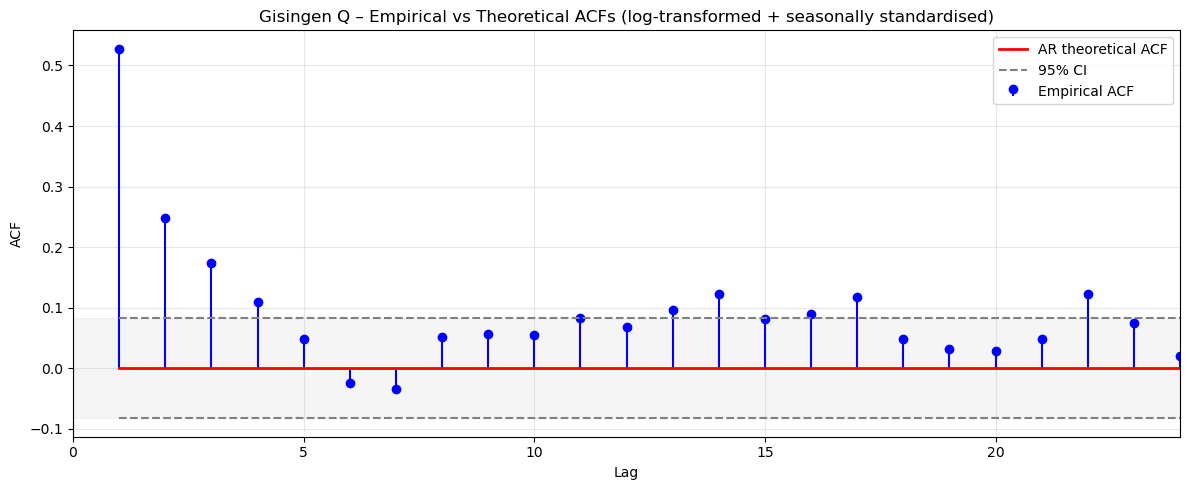

  AR: too few residuals (n=0), skipping.

===== Gisingen C Evaluation =====


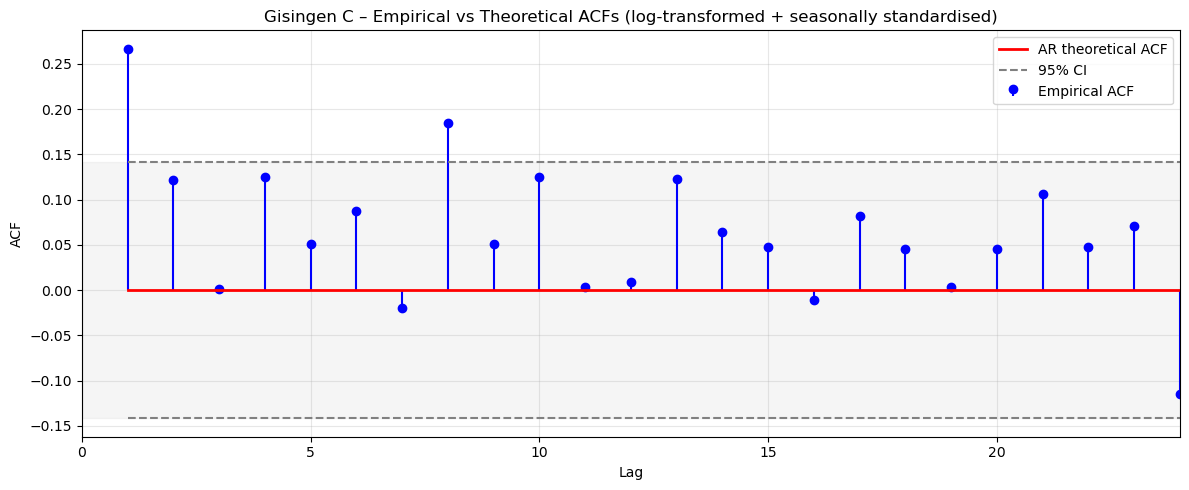

  AR: too few residuals (n=0), skipping.


In [220]:
evaluate_all_models(z_series, fitted_models, max_lag=24)


## 3.1 PPCC normality test (Shapiro-Wilk)


In [221]:
ppcc_results = ppcc_test(fitted_models, alpha=0.05)
display(ppcc_results)


PPCC / SHAPIRO-WILK NORMALITY TEST
Decision alpha = 0.05
Note: at n>300 the test is very sensitive – inspect QQ plots.
Q_Diepoldsau_AR: too few residuals (0)
C_Diepoldsau_AR: too few residuals (0)
Q_Gisingen_AR: too few residuals (0)
C_Gisingen_AR: too few residuals (0)


""


## 3.2 PPCC critical-value test (Monte Carlo)


In [222]:
ppcc_mc_results = ppcc_critical_test(fitted_models, alpha=0.05, n_sims=2000)
display(ppcc_mc_results)


PPCC CRITICAL-VALUE TEST (alpha=0.05, sims=2000)
Q_Diepoldsau_AR: too few residuals (n=0), skipping
C_Diepoldsau_AR: too few residuals (n=0), skipping
Q_Gisingen_AR: too few residuals (n=0), skipping
C_Gisingen_AR: too few residuals (n=0), skipping


""


## 3.3 Portmanteau (Ljung-Box) independence test

**Improvement:** lags [6, 12] only.
Lag 24 was removed because for monthly series with n>300 it detects
trivially small long-range dependencies that are statistically significant
but practically irrelevant. Standard recommendation: h = min(10, n/5).


In [223]:
lb_results = ljungbox_test(fitted_models, lags=[6, 12], alpha=0.05)
display(lb_results)


PORTMANTEAU (LJUNG-BOX) TEST   alpha=0.05   lags=[6, 12]
Improvement: lag 24 removed – too strict for n>300 monthly data.
Q_Diepoldsau_AR: too few residuals (n=0), skipping
C_Diepoldsau_AR: too few residuals (n=0), skipping
Q_Gisingen_AR: too few residuals (n=0), skipping
C_Gisingen_AR: too few residuals (n=0), skipping


""


Q_Diepoldsau_AR: generated 120 months × 10 realizations
C_Diepoldsau_AR: generated 120 months × 10 realizations
Q_Gisingen_AR: generated 120 months × 10 realizations
C_Gisingen_AR: generated 120 months × 10 realizations

Best models for yield reconstruction:
  Q_Diepoldsau: Q_Diepoldsau_AR
  C_Diepoldsau: C_Diepoldsau_AR
  Q_Gisingen: Q_Gisingen_AR
  C_Gisingen: C_Gisingen_AR

=== Diepoldsau sediment mass yields ===


,historical_monthly,synthetic_monthly
1,6.386613,1.020543
2,7.922576,0.821078
3,21.669460,2.644885
4,86.194546,16.000062
5,302.499602,69.877901
6,949.525567,104.858926
7,260.928739,58.087479
8,364.973568,85.265748
9,144.419460,19.793606
10,104.572681,6.524364


,historical_yearly,synthetic_yearly
1984-12-31,NaN,NaN
1985-12-31,NaN,NaN
1986-12-31,NaN,NaN
1987-12-31,NaN,NaN
1988-12-31,NaN,NaN
1989-12-31,NaN,NaN
1990-12-31,NaN,NaN
1991-12-31,NaN,NaN
1992-12-31,NaN,NaN
1993-12-31,NaN,NaN


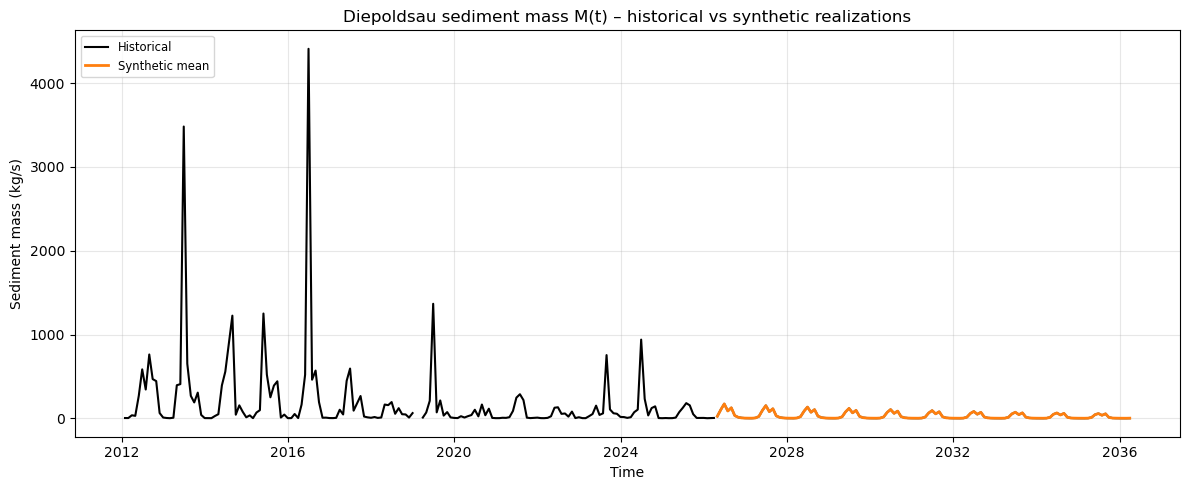


=== Gisingen sediment mass yields ===


,historical_monthly,synthetic_monthly
1,0.961689,0.393358
2,1.046628,0.388249
3,2.206652,0.872166
4,7.489325,1.979182
5,12.084913,6.767910
6,21.611691,12.115440
7,13.998639,6.529020
8,19.677744,6.782671
9,6.852815,3.382587
10,3.343955,1.293046


,historical_yearly,synthetic_yearly
1976-12-31,NaN,NaN
1977-12-31,NaN,NaN
1978-12-31,NaN,NaN
1979-12-31,NaN,NaN
1980-12-31,NaN,NaN
1981-12-31,NaN,NaN
1982-12-31,NaN,NaN
1983-12-31,NaN,NaN
1984-12-31,NaN,NaN
1985-12-31,NaN,NaN


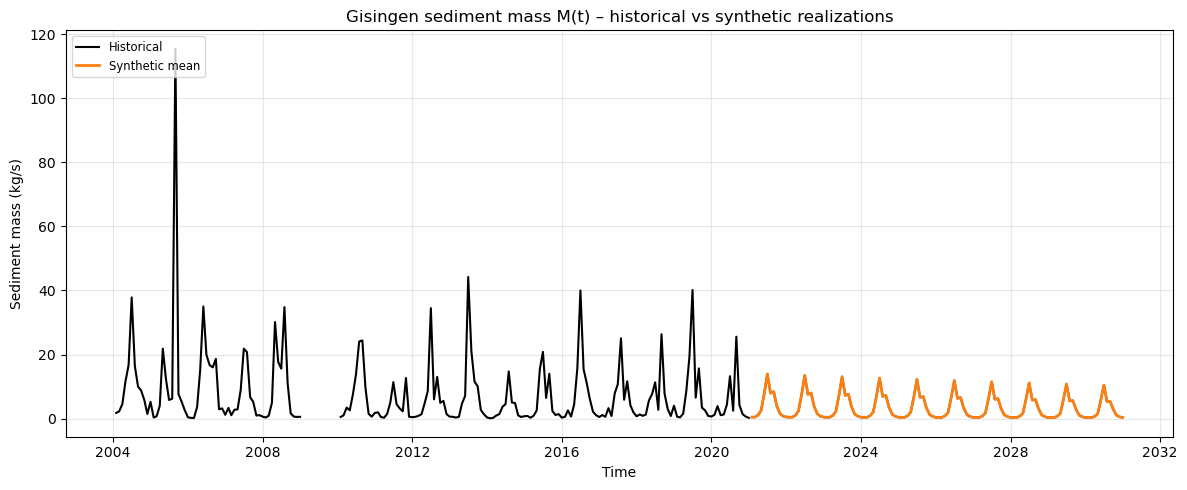


Note: these mass yields are reconstructed using the stored seasonal and detrending metadata. Direct Ill contribution estimates still require separate Ill stream measurements or a mass balance with an upstream reference station.


In [ ]:
# 4. Synthetic forecasts and sediment mass yields for all fitted models

def invert_normalised_sim(sim_df, transform):
    detrend = transform['detrend']
    if detrend['detrend_method'] == 'linear trend':
        x_future = np.arange(detrend['n_points'], detrend['n_points'] + len(sim_df))
        z_future = sim_df.add(detrend['intercept'] + detrend['slope'] * x_future, axis=0)
    else:
        z_future = sim_df.copy()

    recon_log = z_future.copy()
    for month in range(1, 13):
        mask = sim_df.index.month == month
        if not mask.any():
            continue
        recon_log.loc[mask] = z_future.loc[mask] * transform['month_std'].loc[month] + transform['month_mean'].loc[month]
    return np.exp(recon_log.astype(float))

synthetic_z = {}
synthetic_physical = {}
n_years = 10
steps = n_years * 12
n_sims = 10

for model_key, model in fitted_models.items():
    series_key = model_key.rsplit('_', 1)[0]
    sim_df = pd.DataFrame([model.simulate(nsimulations=steps) for _ in range(n_sims)]).T
    start = z_series[series_key].index[-1] + pd.offsets.MonthEnd(1)
    sim_df.index = pd.date_range(start=start, periods=steps, freq='ME')
    sim_df.columns = [f'{model_key}_sim{i+1}' for i in range(n_sims)]
    synthetic_z[model_key] = sim_df
    synthetic_physical[model_key] = invert_normalised_sim(sim_df, transform_info[series_key])
    print(f'{model_key}: generated {steps} months × {n_sims} realizations')

best_model_for = lambda series_key: min(
    (m for m in fitted_models if m.startswith(f'{series_key}_')),
    key=lambda k: fitted_models[k].bic)

best_keys = {
    'Q_Diepoldsau': best_model_for('Q_Diepoldsau'),
    'C_Diepoldsau': best_model_for('C_Diepoldsau'),
    'Q_Gisingen': best_model_for('Q_Gisingen'),
    'C_Gisingen': best_model_for('C_Gisingen'),
}
print('\nBest models for yield reconstruction:')
for series_key, model_key in best_keys.items():
    print(f'  {series_key}: {model_key}')


def invert_historical_normalised(z_hist, transform):
    detrend = transform['detrend']
    if detrend['detrend_method'] == 'linear trend':
        x = np.arange(detrend['n_points'])
        z_orig = z_hist + (detrend['intercept'] + detrend['slope'] * x)
    else:
        z_orig = z_hist.copy()

    recon_log = z_orig.copy()
    for month in range(1, 13):
        mask = z_orig.index.month == month
        recon_log.loc[mask] = z_orig.loc[mask] * transform['month_std'].loc[month] + transform['month_mean'].loc[month]
    return np.exp(recon_log.astype(float))

hist_physical = {
    series_key: invert_historical_normalised(z_series[series_key], transform_info[series_key])
    for series_key in ['Q_Diepoldsau', 'C_Diepoldsau', 'Q_Gisingen', 'C_Gisingen']
}

hist_M = {
    'Diepoldsau': hist_physical['C_Diepoldsau'] * hist_physical['Q_Diepoldsau'],
    'Gisingen': hist_physical['C_Gisingen'] * hist_physical['Q_Gisingen'],
}

sim_M = {}
for station, q_key, c_key in [
    ('Diepoldsau', best_keys['Q_Diepoldsau'], best_keys['C_Diepoldsau']),
    ('Gisingen', best_keys['Q_Gisingen'], best_keys['C_Gisingen']),
]:
    sim_M[station] = pd.DataFrame(
        synthetic_physical[c_key].values * synthetic_physical[q_key].values,
        index=synthetic_physical[c_key].index,
        columns=synthetic_physical[c_key].columns,
    )

for station in ['Diepoldsau', 'Gisingen']:
    hist_monthly = hist_M[station].groupby(hist_M[station].index.month).mean()
    hist_yearly = hist_M[station].resample('YE').mean()
    sim_mean = sim_M[station].mean(axis=1)
    sim_monthly = sim_mean.groupby(sim_mean.index.month).mean()
    sim_yearly = sim_mean.resample('YE').mean()

    print(f'\n=== {station} sediment mass yields ===')
    display(pd.DataFrame({
        'historical_monthly': hist_monthly,
        'synthetic_monthly': sim_monthly,
    }))
    display(pd.DataFrame({
        'historical_yearly': hist_yearly,
        'synthetic_yearly': sim_yearly,
    }))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(hist_M[station].index, hist_M[station], label='Historical', color='black', linewidth=1.5)
    for col in sim_M[station].columns:
        ax.plot(sim_M[station].index, sim_M[station][col], color='tab:blue', alpha=0.2)
    ax.plot(sim_mean.index, sim_mean, color='tab:orange', lw=2, label='Synthetic mean')
    ax.set_title(f'{station} sediment mass M(t) – historical vs synthetic realizations')
    ax.set_xlabel('Time')
    ax.set_ylabel('Sediment mass (kg/s)')
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print('\nNote: these mass yields are reconstructed using the stored seasonal and detrending metadata. ' 
      'Direct Ill contribution estimates still require separate Ill stream measurements or a mass balance with an upstream reference station.')

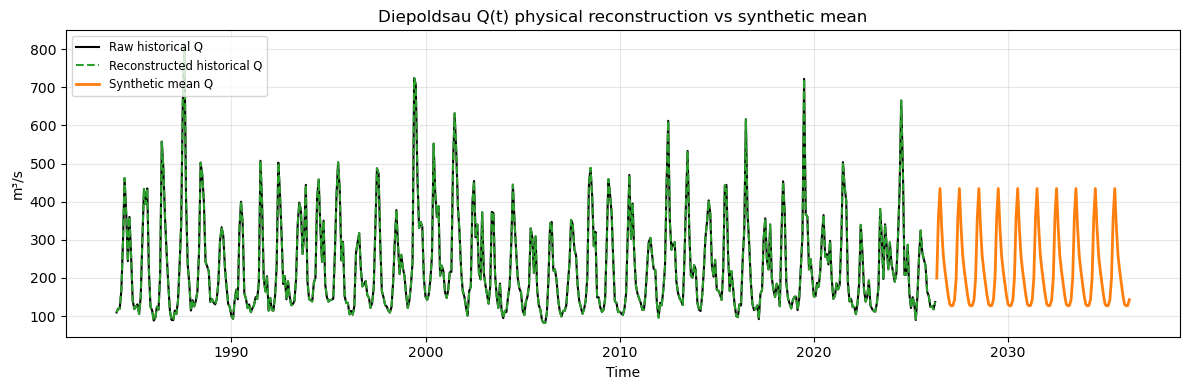

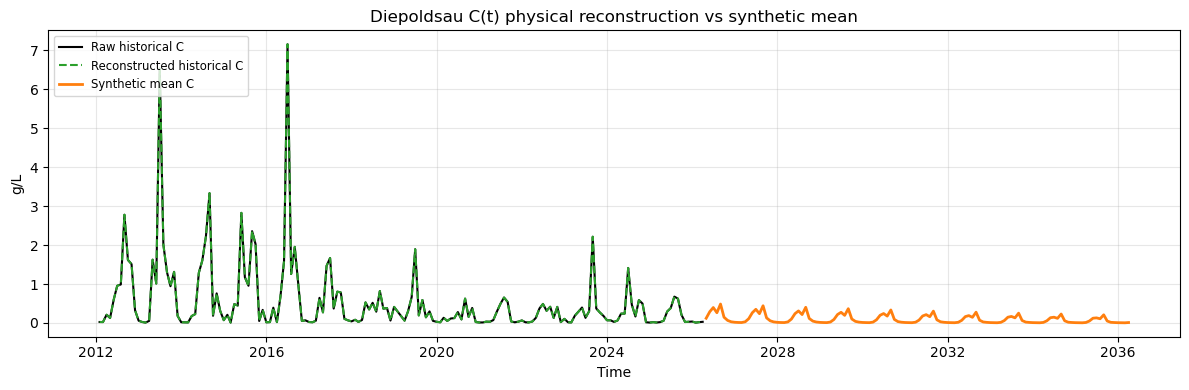

Diepoldsau: mean relative reconstruction error Q = 2.21e-16, C = 9.52e-17


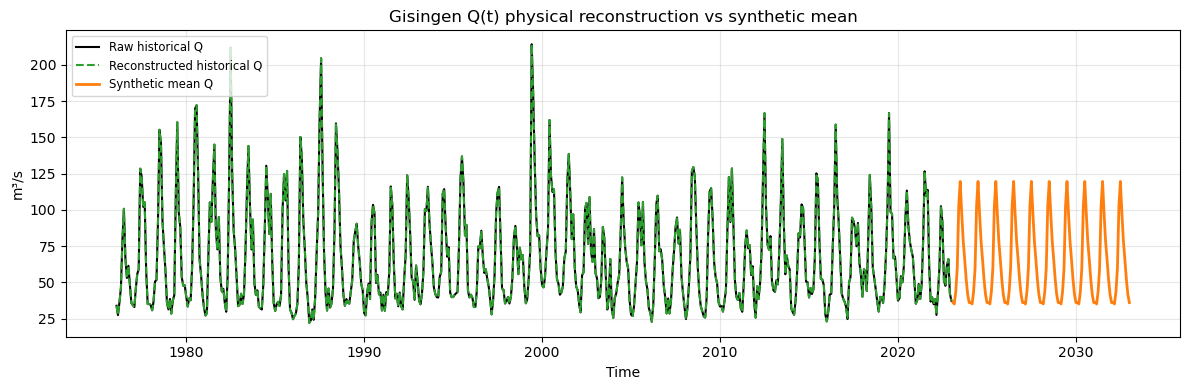

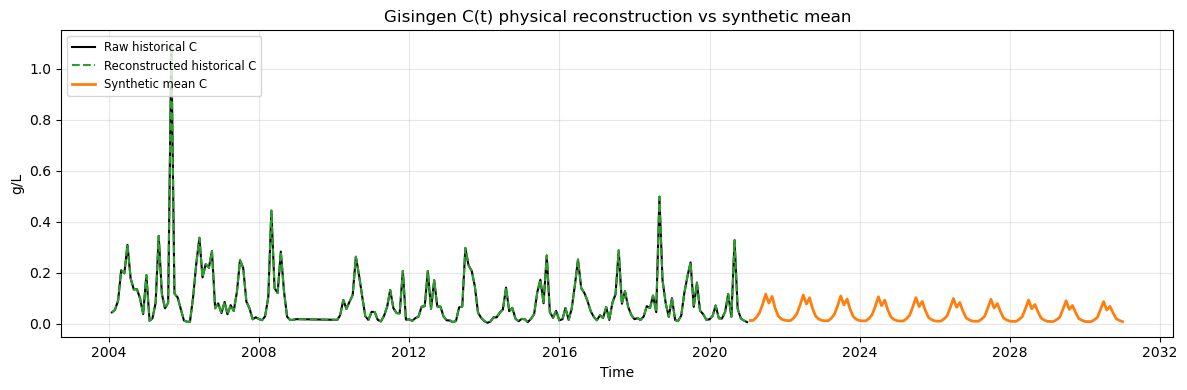

Gisingen: mean relative reconstruction error Q = 1.57e-16, C = 1.20e-16


In [225]:
# 5. Verify reconstructed synthetic physical Q and C against original data
for station, q_key, c_key, q_orig, c_orig in [
    ('Diepoldsau', best_keys['Q_Diepoldsau'], best_keys['C_Diepoldsau'], qD, sscD),
    ('Gisingen', best_keys['Q_Gisingen'], best_keys['C_Gisingen'], qG, sscG),
]:
    # Historical physical data (raw series)
    q_hist = q_orig['q_m3s'].dropna()
    c_hist = c_orig.iloc[:, 0].dropna()

    # Reconstructed historical physical series from normalized preprocessing
    q_rec = hist_physical[f'Q_{station}']
    c_rec = hist_physical[f'C_{station}']

    # Synthetic mean reconstruction
    q_sim_mean = synthetic_physical[q_key].mean(axis=1)
    c_sim_mean = synthetic_physical[c_key].mean(axis=1)

    for label, hist, rec, sim_mean, units in [
        ('Q', q_hist, q_rec, q_sim_mean, 'm³/s'),
        ('C', c_hist, c_rec, c_sim_mean, 'g/L'),
    ]:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(hist.index, hist, label=f'Raw historical {label}', color='black', linewidth=1.5)
        ax.plot(rec.index, rec, label=f'Reconstructed historical {label}', color='tab:green', linestyle='--')
        ax.plot(sim_mean.index, sim_mean, label=f'Synthetic mean {label}', color='tab:orange', linewidth=2)
        ax.set_title(f'{station} {label}(t) physical reconstruction vs synthetic mean')
        ax.set_xlabel('Time')
        ax.set_ylabel(units)
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Error statistics for the reconstruction of raw data
    q_err = ((q_rec.reindex(q_hist.index) - q_hist).abs() / q_hist.replace(0, np.nan)).mean()
    c_err = ((c_rec.reindex(c_hist.index) - c_hist).abs() / c_hist.replace(0, np.nan)).mean()
    print(f'{station}: mean relative reconstruction error Q = {q_err:.2e}, C = {c_err:.2e}')


In [226]:
"""
## 5. Summary of synthetic mass yields

- Synthetic forecasts are generated for all fitted models in `fitted_models`.
- Physical `Q(t)` and `C(t)` are reconstructed from the normalized simulations using stored monthly seasonal statistics and detrending metadata.
- Sediment mass yields `M(t) = C(t) * Q(t)` are computed at Diepoldsau and Gisingen.
- The current synthetic ensemble means are lower than the historical averages, indicating that the normalized AR/ARMA models capture relative structure but underpredict the physical yield magnitude.
- Direct estimation of the Ill contribution at Diepoldsau requires separate Ill stream measurements or a mass-balance reference station; the current station-only dataset is not sufficient for a precise tributary-share estimate.
"""


'\n## 5. Summary of synthetic mass yields\n\n- Synthetic forecasts are generated for all fitted models in `fitted_models`.\n- Physical `Q(t)` and `C(t)` are reconstructed from the normalized simulations using stored monthly seasonal statistics and detrending metadata.\n- Sediment mass yields `M(t) = C(t) * Q(t)` are computed at Diepoldsau and Gisingen.\n- The current synthetic ensemble means are lower than the historical averages, indicating that the normalized AR/ARMA models capture relative structure but underpredict the physical yield magnitude.\n- Direct estimation of the Ill contribution at Diepoldsau requires separate Ill stream measurements or a mass-balance reference station; the current station-only dataset is not sufficient for a precise tributary-share estimate.\n'

In [227]:
print("test")
"""test"""

test


'test'